In [1]:
#from utils2 import *
from utils import *

import numpy as np
import time
import json

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATSx
from neuralforecast.losses.pytorch import HuberLoss
from neuralforecast.losses.pytorch import MQLoss
from neuralforecast.losses.pytorch import MSE
from neuralforecast.utils import AirPassengersPanel, AirPassengersStatic

from pytorch_lightning.callbacks import TQDMProgressBar
from lightning.pytorch.loggers import CSVLogger

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
 


Using cuda (NVIDIA GeForce RTX 2060)


In [ ]:
# load data
df = load_df()

# calcula las fechas de los datasets de TRAIN, VAL y TEST
dates = calulate_train_validation_test_dates(df)

# scale df
df_scaled_original, target_scaler = scale_df(df, dates)

# adapt
df_scaled = df_scaled_original.copy()
df_scaled = df_scaled.reset_index(drop=False)
df_scaled["ds"] = df_scaled[DATETIME_COL]
df_scaled["y"] = df_scaled["target_log_return_scaled"]
df_scaled['unique_id'] = 'TICKER' # or per-ticker symbol if you have many

# add features
column_names = []
for feature in FEATURES:
    column_names.append(feature + "_scaled")
df_scaled = df_scaled.reset_index()
df_scaled = df_scaled[[DATETIME_COL] + column_names + ["ds", "y", "unique_id"]]

# Keep only what’s needed
df_scaled = df_scaled[['unique_id','ds','y'] + column_names + [DATETIME_COL]].sort_values(['unique_id','ds'])

# split in train / validation /test
df_scaled = df_scaled.set_index(DATETIME_COL)
df_scaled_train, df_scaled_validation, df_scaled_test = split_df(df_scaled, dates)

# reset indexes
df_scaled_train = df_scaled_train.reset_index(drop=True)
df_scaled_validation = df_scaled_validation.reset_index(drop=True)
df_scaled_test = df_scaled_test.reset_index(drop=True)
 
df_scaled_train.describe()

,ds,y,close_scaled,log_volume_scaled,date_hour_scaled,date_day_scaled,date_month_scaled,ema_ratio_scaled,ema_spread_scaled,macd_histogram_scaled,macd_scaled,macd_signal_scaled,volatility_24h_scaled,obv_scaled,sofr_scaled,vix_scaled,log_return_scaled
count,24469,2.446900e+04,24469.000000,24469.000000,24469.000000,24469.000000,24469.000000,24469.000000,24469.000000,24469.000000,24469.000000,24469.000000,24469.000000,24469.000000,24469.000000,24469.000000,24469.000000
mean,2022-05-29 04:59:59.999999744,2.903849e-18,0.407419,0.356161,0.500127,0.499407,0.473564,0.521296,0.537200,0.562556,0.521125,0.515763,0.337351,0.446073,0.377716,0.337596,-0.000015
min,2021-01-04 11:00:00,-3.589353e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.589353
25%,2021-09-16 08:00:00,-1.460693e-02,0.264538,0.000000,0.260870,0.166667,0.181818,0.412351,0.430237,0.492425,0.420762,0.407562,0.079756,0.213730,0.007519,0.179582,-0.014607
50%,2022-05-29 05:00:00,-1.460693e-02,0.338150,0.000000,0.521739,0.500000,0.454545,0.533959,0.548408,0.565382,0.528763,0.522592,0.375820,0.393010,0.144737,0.295203,-0.014607
75%,2023-02-08 02:00:00,-1.460693e-02,0.500917,0.749354,0.782609,0.833333,0.727273,0.628843,0.640914,0.632842,0.618652,0.624567,0.521676,0.666065,0.853383,0.467815,-0.014607
max,2023-10-20 23:00:00,3.585989e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.585989
std,NaN,1.000020e+00,0.252393,0.398614,0.300965,0.333041,0.300602,0.150427,0.152743,0.116778,0.146443,0.155481,0.237535,0.285763,0.404140,0.206227,1.000023


In [ ]:
# calcula el margin con el metodo percentiles

# metodo percentiles
df_train, _, _ = split_df(df, dates) 

porcentage_neutral = 0.4
q = (1 - porcentage_neutral) / 2.0

target_non_zero = df_train[TARGET].values
threshold = 0.0001
theta_minus = min(float(np.quantile(target_non_zero, q)), -threshold)
theta_plus  = max(float(np.quantile(target_non_zero, 1 - q)), threshold)

print(theta_minus, theta_plus, q, df_train[TARGET].std())


-5e-05 5e-05 0.3 0.0025671181617078903


In [ ]:
# hyperparametros
num_epochs = 500
learning_rate = 0.001
input_size  = ROLLING_WINDOW_SIZE
frequency = FREQUENCY
dropout = 0.3
batch_size=256
valid_batch_size=256
metrics = {}
loss_fn = HuberLoss() 
optimizer = torch.optim.AdamW

# logger a disco
csv_logger = CSVLogger(save_dir="lightning_logs", name="nbeatsx_run", version="latest")

# define modelo
model = NBEATSx(
    h=FORECAST_LENGTH,
    input_size=input_size,
    loss=loss_fn,

    # Architecture (2 stacks: identity + exogenous; valid when h=1)
    stack_types=["identity", "exogenous"],    
    n_blocks=[1,1],         
    mlp_units=[[128, 128],[128, 128]],    
    dropout_prob_theta=dropout,   
    activation = "LeakyReLU", # solo afecta a las capas ocultas
    
    # Optimisation
    learning_rate=learning_rate,
    optimizer=optimizer,
    batch_size=batch_size,
    valid_batch_size=valid_batch_size,
    max_steps=num_epochs,    
    #early_stop_patience_steps=None,
    random_seed=SEED,
    
    # Scaling & features
    scaler_type="standard", 
    #scaler_type="robust", 
    hist_exog_list=column_names,    # all your observed features go here
    val_check_steps=1,              # make sure it evaluates validation every epoch
    logger=csv_logger
    # futr_exog_list=[...],         # only if you truly know them in advance
    # stat_exog_list=[...],         # static per-series attrs if you have multiple tickers
    # enable_progress_bar=False,    # <- direct Trainer kw
    
)
nf = NeuralForecast(models=[model], freq=frequency) 

# concatenate train + validation 
df_scaled_train_and_validation = pd.concat([df_scaled_train, df_scaled_validation], ignore_index=True)

# train modelo
start = time.time()
nf.fit(df=df_scaled, val_size=len(df_scaled_validation), verbose=0)
end =time.time()
metrics["train_ms"] = (end - start)


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer(val_check_interval=1)` was configured so validation will run after every batch.
D:\Reps\master-ia\10.- Trabajo fin de master\scripts\venv\Lib\site-packages\lightning\fabric\loggers\csv_logs.py:268: Experiment logs directory lightning_logs\nbeatsx_run\latest exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | HuberLoss     | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 345 K  | train
-------------------------------------------------------
345 K     Trainable params
0         Non-trainable params
345 K     Total params
1.381    

Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_steps=500` reached.


In [5]:

# Contar parámetros totales y entrenables
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Calcular tamaño en MB (float32 = 4 bytes)
model_size_mb = trainable_params * 4 / 1024**2
print(f"Trainable parameters: {trainable_params:,}")
print(f"Approx. model size: {model_size_mb:.2f} MB")

Trainable parameters: 345,218
Approx. model size: 1.32 MB


       train_loss_epoch  valid_loss
epoch                              
0              0.672415    0.447032
1              0.684888    0.442980
2              0.586475    0.444058
3              0.684148    0.442612
4              0.650622    0.440893
...                 ...         ...
495            0.403182    0.272344
496            0.487233    0.272658
497            0.312735    0.272852
498            0.356030    0.272955
499            0.406171    0.273124

[500 rows x 2 columns]


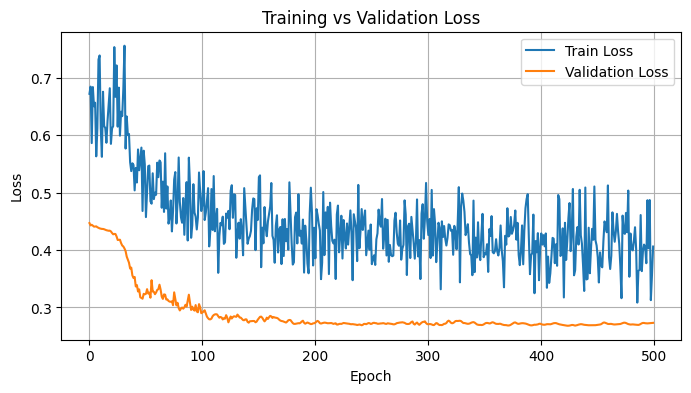

In [6]:
# read metrics
df_metrics = pd.read_csv("lightning_logs/nbeatsx_run/latest/metrics.csv")

df_metrics = df_metrics[["epoch", "train_loss_epoch", "valid_loss"]]

# el fichero CSV contiene 
df_metrics["train_loss_epoch"] = df_metrics["train_loss_epoch"].where(
    df_metrics["train_loss_epoch"] <= 1, np.nan
)

# agr
def last_notna(series):
    s = series.dropna()
    return s.iloc[-1] if len(s) else np.nan
summary = (
    df_metrics.groupby("epoch", as_index=True).agg({
          "train_loss_epoch": last_notna,
          "valid_loss":     last_notna     # or "valid_loss"
      })
)

# interpolate
summary['train_loss_epoch'] = summary['train_loss_epoch'].interpolate(method='linear')

print(summary)

# plot
plt.figure(figsize=(8,4))
plt.plot(summary.index, summary['train_loss_epoch'], label='Train Loss')
plt.plot(summary.index, summary['valid_loss'],     label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# explicación:
# - validation loss 
#   - baja rápidamente de 0.42 a 0.26
#   - muy suave despues de la epoch 200 (buena evidencia de generalización consistente)
# - training loss:
#   - ruido:
#   - está ligeramente por encima de la curva de validación, lo que no representa ningún problema

# no se aprecia overfiting: 
# el gap entre train/validation suele significar que la regularización es efectiva (dropout) o que el dataset de validacion es "mas fácil" que el de entreno
# estabilidad en el entrno: el ruido de la curva de train, se debe a minibatch variability


In [7]:
# predict

# predict train and validation
start = time.time()
df_scaled_train_predict, df_scaled_validation_predict, df_scaled_test_predict = split_df(df_scaled_original, dates)
y_train_validation_predict = nf.predict_insample()["NBEATSx"]
y_train_predict = y_train_validation_predict[:len(df_scaled_train)]
y_validation_predict = y_train_validation_predict[-len(df_scaled_validation_predict):]
end =time.time()
metrics["train_predict_ms"] = (end - start)

# predict test
start = time.time()
y_test_predict = nf.cross_validation(
    df=pd.concat([df_scaled_train, df_scaled_validation, df_scaled_test], ignore_index=True), 
    n_windows=len(df_scaled_test), 
    step_size=FORECAST_LENGTH, 
    refit=False, 
    verbose=0)["NBEATSx"]
end =time.time()
metrics["test_predict_ms"] = (end - start)

display(y_test_predict)


D:\Reps\master-ia\10.- Trabajo fin de master\scripts\venv\Lib\site-packages\utilsforecast\processing.py:384: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer(val_check_interval=1)` was configured so validation will run after every batch.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                                 …

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer(val_check_interval=1)` was configured so validation will run after every batch.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | HuberLoss     | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 345 K  | train
-------------------------------------------------------
345 K     Trainable params
0         Non-trainable params
345 K     Total params
1.381     Total estimated model params size (MB)
23        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer(val_check_interval=1)` was configured so validation will run after every batch.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                                 …

0      -0.012550
1      -0.017377
2      -0.022965
3      -0.019402
4      -0.023341
          ...   
5274    0.060352
5275    0.259955
5276   -0.395042
5277    0.066759
5278   -0.024934
Name: NBEATSx, Length: 5279, dtype: float32

In [ ]:

# append predict results to dataframes
add_predictions_to_df(df_scaled_train_predict, y_train_predict.values, target_scaler, df_scaled_train_predict.iloc[0]["close"])
add_predictions_to_df(df_scaled_validation_predict, y_validation_predict.values, target_scaler, df_scaled_validation_predict.iloc[0]["close"])
add_predictions_to_df(df_scaled_test_predict, y_test_predict.values, target_scaler, df_scaled_validation_predict.iloc[-1]["predict_close_accumulated"])



24469 24469
5232 5232
5279 5279


In [9]:
# eval metrics
metrics["train"]  = evaluate_metrics_df(df_scaled_train_predict)
metrics["validation"] = evaluate_metrics_df(df_scaled_validation_predict)
metrics["test"] = evaluate_metrics_df(df_scaled_test_predict)


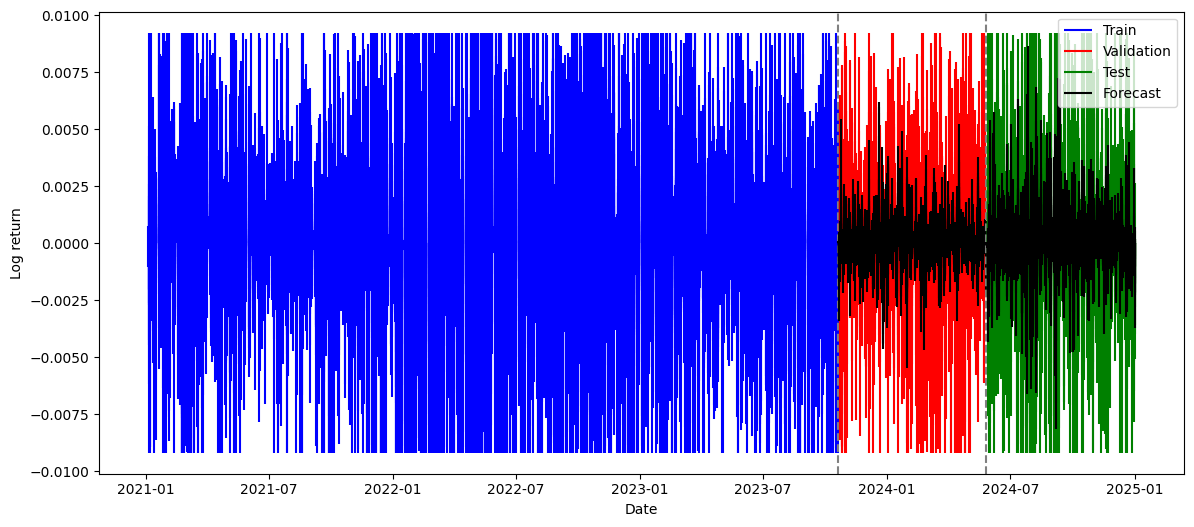

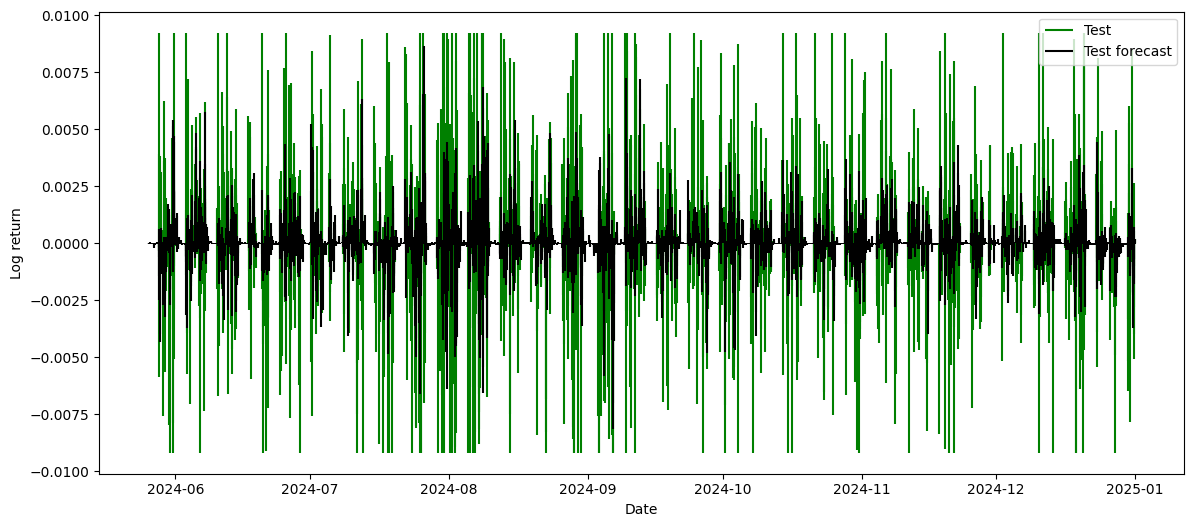

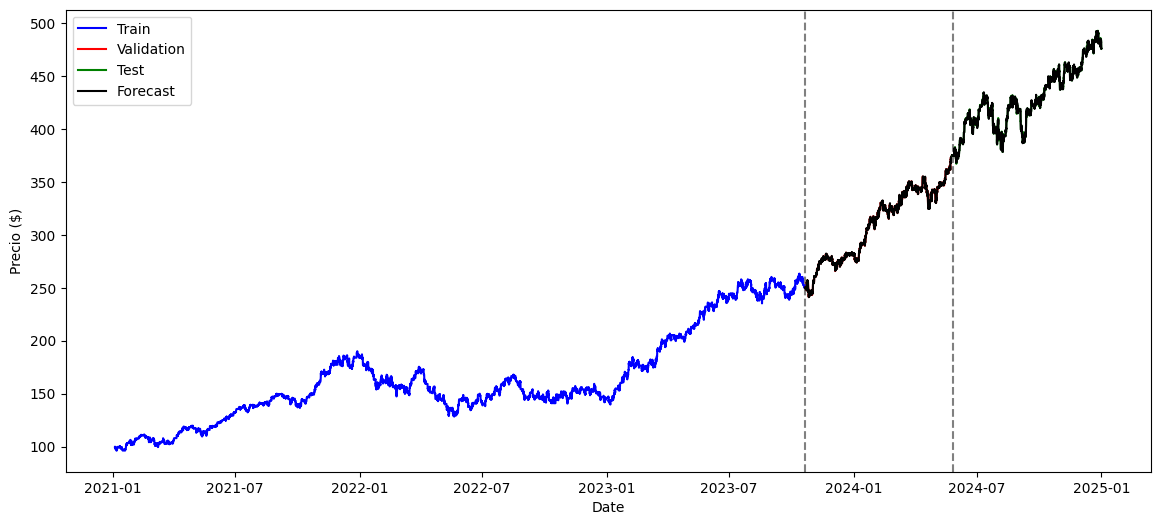

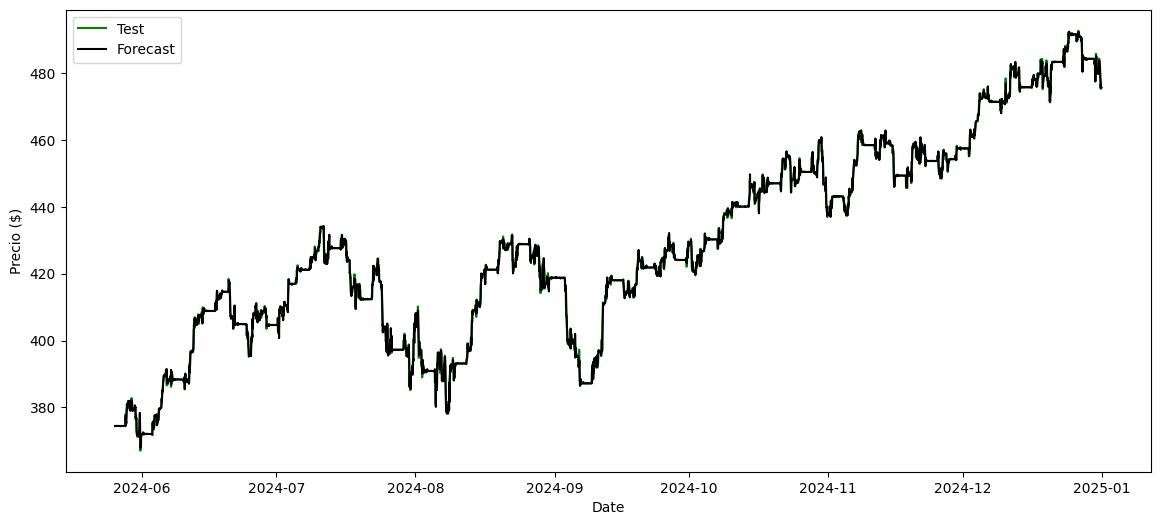

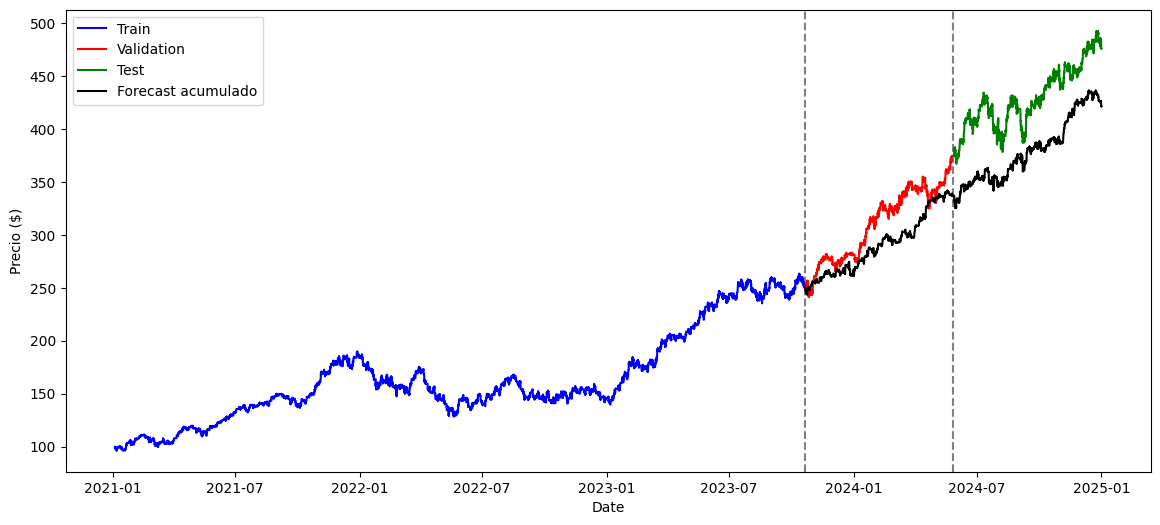

In [10]:

# plot
plot_df(df_scaled_train_predict, df_scaled_validation_predict, df_scaled_test_predict, False)

In [11]:
# Suppose y_dir contains your direction labels (-1, 0, +1)
unique, counts = np.unique(df_scaled_test_predict[["target_direction"]].to_numpy(), return_counts=True)
probs = counts / counts.sum()

print("Class distribution TARGET:")
for u, p in zip(unique, probs):
    print(f"{u}: {p:.2%}")

# Suppose y_dir contains your direction labels (-1, 0, +1)
unique, counts = np.unique(df_scaled_test_predict[["predict_direction"]].to_numpy(), return_counts=True)
probs = counts / counts.sum()

print("Class distribution PREDICT:")
for u, p in zip(unique, probs):
    print(f"{u}: {p:.2%}")    

Class distribution TARGET:
-1: 20.52%
0: 56.75%
1: 22.73%
Class distribution PREDICT:
-1: 22.50%
0: 51.05%
1: 26.44%


In [12]:
# ANOVA test
anova_result = f_oneway(
    df_scaled_train_predict["error_log_return"],
    df_scaled_validation_predict["error_log_return"],
    df_scaled_test_predict["error_log_return"]
)
metrics["anova"] = { "f_statistic": anova_result.statistic, "p_value": anova_result.pvalue}

# print
print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)
df_scaled_train_predict["predict_log_return"][1000:2000].sum()

F-statistic: 0.19138231388386087
p-value: 0.8258176713378327


np.float32(0.06979853)

Confusion Matrix (Counts):
              Pred Down  Pred Neutral  Pred Up
True Down           476           117      490
True Neutral        234          2471      291
True Up             478           107      615 

Confusion Matrix (Percentages):
             Pred Down Pred Neutral Pred Up
True Down       43.95%        10.8%  45.24%
True Neutral     7.81%       82.48%   9.71%
True Up         39.83%        8.92%  51.25%


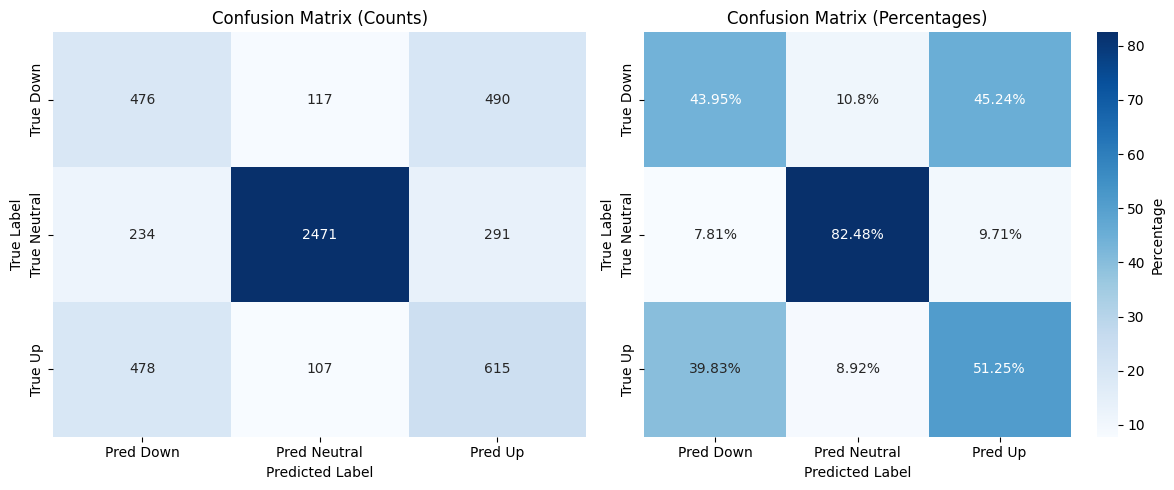

In [13]:
# plot confusion matrix
cm_counts, cm_percent = plot_confusion_matrix(df_scaled_test_predict, true_col="target_direction", pred_col="predict_direction")

In [15]:
# show metrics
print(json.dumps(metrics, indent=4) )

{
    "train_ms": 20.33003568649292,
    "train_predict_ms": 0.17043304443359375,
    "test_predict_ms": 15.36316967010498,
    "train": {
        "mse": 5.8895523341152875e-06,
        "rmse": 0.002426839989392644,
        "mae": 0.001203014595139712,
        "huber": 2.9447761670576438e-06,
        "r2": 0.10626592606725593,
        "mape": null,
        "smape": null,
        "aic": null,
        "bic": null,
        "pearson_r": 0.3276011244249786,
        "spearman_rho": 0.2465425180645167,
        "direction": 69.35714577628836,
        "sharpe": 0.17626714968470397
    },
    "validation": {
        "mse": 4.688681114701066e-06,
        "rmse": 0.0021653362590371653,
        "mae": 0.0011936904322901098,
        "huber": 2.344340557350533e-06,
        "r2": -0.1349003898701473,
        "mape": null,
        "smape": null,
        "aic": null,
        "bic": null,
        "pearson_r": 0.010224067274344013,
        "spearman_rho": -0.0018205137003712007,
        "direction": 43.36

In [16]:
# save 
save_result("NBEATS", metrics, df_scaled_train_predict, df_scaled_validation_predict, df_scaled_test_predict)
